# This notebook is used to generate figures for the presentation on ExactBO

## 1 - BO vs ExactBO Domain Management

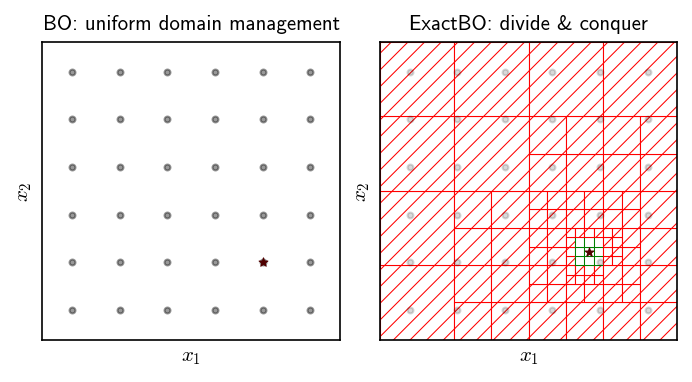

In [70]:
# Matplotlib figure for BO vs ExactBO (1x2), CM Sans, 10pt, 4.5x3.5 in
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# --- typography & style ---
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Set global hatch linewidth
plt.rcParams['hatch.linewidth'] = 0.5

# LaTeX rendering optional (turn on if your env supports it)
# mpl.rcParams.update({
#     "text.usetex": True,
#     "text.latex.preamble": r"\usepackage{sfmath}\renewcommand{\familydefault}{\sfdefault}"
# })

aggiemaroon = np.array([[80/255, 0, 0]])

fig, axs = plt.subplots(1, 2, figsize=(4.5, 2.4), constrained_layout=True)

# Common axis setup
for ax in axs:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

# --- Left: BO grid with best next point ---
ax = axs[0]
ax.set_title("BO: uniform domain management")

# grid points
gx = np.linspace(0.1, 0.9, 6)
gy = np.linspace(0.1, 0.9, 6)
X, Y = np.meshgrid(gx, gy)
ax.scatter(X, Y, s=8, c="black", alpha=0.4)

# best next point (star)
best_pt_BO = (0.74, 0.26)
ax.scatter(*best_pt_BO, s=20, marker="*", c=aggiemaroon, edgecolor=aggiemaroon, linewidth=0.5, zorder=5)

# --- Right: ExactBO divide & conquer (recursive tiling) ---
ax = axs[1]
ax.set_title("ExactBO: divide & conquer")

best_pt = (0.7, 0.3)
active_color = (0.0, 0.5, 0.0)

def subdivide(x, y, w, h, depth, max_depth, focus_pt, focus_radius):
    """Recursive quadtree subdivision."""
    cx = x + w / 2
    cy = y + h / 2
    dist = ((cx - focus_pt[0])**2 + (cy - focus_pt[1])**2) ** 0.5

    # Decide whether to subdivide further
    if depth < max_depth and dist < focus_radius * (2 ** (max_depth - depth)):
        # split into 4
        hw, hh = w / 2, h / 2
        subdivide(x,     y,     hw, hh, depth+1, max_depth, focus_pt, focus_radius)
        subdivide(x+hw,  y,     hw, hh, depth+1, max_depth, focus_pt, focus_radius)
        subdivide(x,     y+hh,  hw, hh, depth+1, max_depth, focus_pt, focus_radius)
        subdivide(x+hw,  y+hh,  hw, hh, depth+1, max_depth, focus_pt, focus_radius)
    else:
        # leaf tile
        is_active = (dist < focus_radius)
        if is_active:
            ax.add_patch(Rectangle((x, y), w, h, facecolor="white",
                                   edgecolor=active_color, linewidth=0.5))
        else:
            ax.add_patch(Rectangle((x, y), w, h, facecolor="white",
                                   edgecolor="red", linewidth=0.5))
            ax.add_patch(Rectangle((x, y), w, h, facecolor="none",
                                   edgecolor="red", linewidth=0.5, hatch="///"))

# Parameters for the recursive look
subdivide(0.0, 0.0, 1.0, 1.0, depth=0, max_depth=5, focus_pt=best_pt, focus_radius=0.05)

# best point (same star)
best_pt_eBO = (0.703, 0.294)
ax.scatter(X, Y, s=8, c="black", alpha=0.15)
ax.scatter(*best_pt_eBO, s=20, marker="*", c=aggiemaroon, edgecolor=aggiemaroon, linewidth=0.5, zorder=5)

plt.show()
fig.savefig("Figures/bo_vs_exactbo.png", dpi=500)
fig.savefig("Figures/bo_vs_exactbo_transparent.png", dpi=500, transparent=True)

## 2 - Kernel Bounding

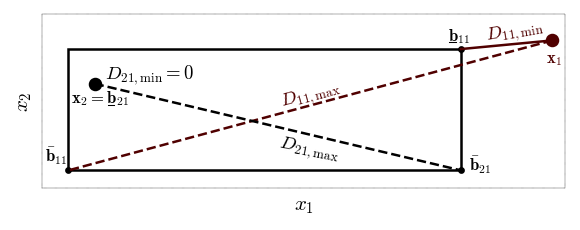

In [94]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# Style consistent with your deck
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
})

aggiemaroon = np.array([[80/255, 0, 0]])

fig, ax = plt.subplots(1, 1, figsize=(4.5, 1.5))

# Hyperbox
box = (0.1, 0.1, 1.5, 0.7)  # x, y, w, h
ax.add_patch(Rectangle((box[0], box[1]), box[2], box[3],
                       facecolor="white", edgecolor="black", linewidth=1.2))
ax.scatter([box[0], box[0]+box[2], box[0]+box[2]], [box[1], box[1], box[1]+box[3]], s=5, c="black")  # bottom corners

# Points
p1 = (1.95, 0.85)  # outside
p2 = (0.20, 0.6)  # inside
ax.scatter(*p1, s=30, c=aggiemaroon, zorder=5)
ax.text(p1[0]-0.025, p1[1] - 0.13, r"$\mathbf{x}_1$", color=aggiemaroon, fontsize=8)
ax.scatter(*p2, s=30, c="black", zorder=5)
ax.text(p2[0]-0.09, p2[1] - 0.11, r"$\mathbf{x}_2=\mathbf{b}_{21}$", color="black", fontsize=8)
ax.plot([p2[0]+0.05, p2[0]+0.075], [p2[1]-0.12, p2[1]-0.12], color="black", linewidth=0.5)

# Min/max distance lines for p1 (outside)
# Min distance: to closest corner/edge (approx: to top-right corner here)
closest = (box[0] + box[2], box[1] + box[3])
ax.plot([p1[0], closest[0]], [p1[1], closest[1]], color=aggiemaroon, linewidth=1.2)
ax.text((p1[0]+closest[0])/2 + 0.03, (p1[1]+closest[1])/2 + 0.03, r"$D_{11,\min}$",
        color=aggiemaroon, ha="center", rotation=10, fontsize=9)
ax.text(closest[0]-0.05, closest[1] + 0.05, r"$\mathbf{b}_{11}$", color="black", fontsize=8)
ax.plot([closest[0]-0.045, closest[0]-0.02], [closest[1]+0.04, closest[1]+0.04], color="black", linewidth=0.5)

# Max distance: to farthest corner
farthest = (box[0], box[1])
ax.plot([p1[0], farthest[0]], [p1[1], farthest[1]], color=aggiemaroon,
        linewidth=1.2, linestyle="--")
ax.text((p1[0]+farthest[0])/2, (p1[1]+farthest[1])/2, r"$D_{11,\max}$",
        color=aggiemaroon, ha="center", rotation=15, fontsize=9)
ax.text(farthest[0]-0.09, farthest[1]+0.05, r"$\bar{\mathbf{b}}_{11}$", color="black", fontsize=8)

# Min/max distance lines for p2 (inside)
# Min distance: zero (point inside)
ax.text(p2[0] + 0.04, p2[1] + 0.03, r"$D_{21,\min}=0$", color="black", fontsize=9)

# Max distance: to farthest corner
farthest2 = (box[0] + box[2], box[1])
ax.plot([p2[0], farthest2[0]], [p2[1], farthest2[1]], color="black",
        linewidth=1.2, linestyle="--")
ax.text((p2[0]+farthest2[0])/2+0.12, (p2[1]+farthest2[1])/2 - 0.18, r"$D_{21,\max}$",
        color="black", ha="center", rotation=-11, fontsize=9)
ax.text(farthest2[0]+0.03, farthest2[1], r"$\bar{\mathbf{b}}_{21}$", color="black", fontsize=8)

# Axes and cleanup
ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
#ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.2)
    spine.set_linestyle("dotted")

fig.savefig("Figures/kernel_bounds.png", dpi=500)  # no tight bbox to avoid clipping
fig.savefig("Figures/kernel_bounds_transparent.png", dpi=500, transparent=True)
plt.show()


## 3 - Normal PDF and CDF

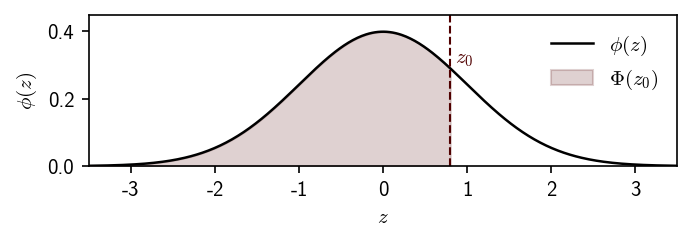

In [104]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import erf, sqrt

# Same typography/style as previous cells
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
    "axes.unicode_minus": False,
})

aggiemaroon = np.array([[80/255, 0, 0]])

def phi(z):
    return 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * z**2)

def Phi(z):
    return 0.5 * (1 + erf(z / sqrt(2)))

z = np.linspace(-3.5, 3.5, 400)
z0 = 0.8  # pick any example cutoff

fig, ax = plt.subplots(figsize=(4.5, 1.5), constrained_layout=True)
ax.plot(z, phi(z), color="black", lw=1.2, label=r"$\phi(z)$")

# shade Φ(z0)
mask = z <= z0
ax.fill_between(z[mask], phi(z)[mask], color=aggiemaroon[0], alpha=0.18,
                label=rf"$\Phi(z_0)$")
ax.axvline(z0, color=aggiemaroon[0], lw=1.0, ls="--")
ax.text(z0 + 0.05, phi(z0) + 0.015, rf"$z_0$", color=aggiemaroon[0])

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(0, 0.45)
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\phi(z)$")
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.show()
fig.savefig("Figures/phi_cdf_shaded_transparent.png", dpi=500, transparent=True)
fig.savefig("Figures/phi_cdf_shaded.png", dpi=500)


## 4 - DIRECT Algorithm

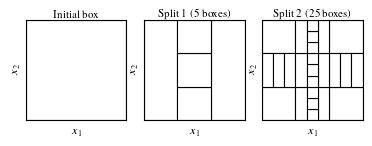

Saved figure to /Users/juanesfco/tamubo/development/figures/direct_splits.pdf


In [3]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

mpl.rcParams.update(
    {
        # Match the asmeconf class more closely by letting LaTeX typeset the figure text.
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage[helvratio=.91]{newtxtext}\usepackage{newtxmath}",
        "font.family": "serif",
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "axes.labelweight": "regular",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 8,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "lines.markersize": 4.0,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
    }
)

FIGURE_WIDTH_PT = 257.28102
INCHES_PER_PT = 1.0 / 72.27
figure_width = FIGURE_WIDTH_PT * INCHES_PER_PT
figure_height = figure_width * (1.6 / 4.5)

NOTEBOOK_NAME = "exactBO_presentation.ipynb"
candidate_dirs = [Path.cwd(), Path.cwd() / "development"]
notebook_dir = next(
    (path for path in candidate_dirs if (path / NOTEBOOK_NAME).exists()),
    Path.cwd(),
)
output_dir = notebook_dir / "figures"
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "direct_splits.pdf"

def subdivide_direct(rect):
    """Split the longest side into thirds, then split the middle slab on the other axis."""
    x, y, w, h = rect
    if w >= h:
        w3 = w / 3
        left = (x, y, w3, h)
        right = (x + 2 * w3, y, w3, h)
        mid_x = (x + w3, y, w3, h)
        h3 = h / 3
        mid_b = (mid_x[0], y, w3, h3)
        mid_m = (mid_x[0], y + h3, w3, h3)
        mid_t = (mid_x[0], y + 2 * h3, w3, h3)
        return [left, right, mid_b, mid_m, mid_t]

    h3 = h / 3
    bottom = (x, y, w, h3)
    top = (x, y + 2 * h3, w, h3)
    mid_y = (x, y + h3, w, h3)
    w3 = w / 3
    mid_l = (x, mid_y[1], w3, h3)
    mid_m = (x + w3, mid_y[1], w3, h3)
    mid_r = (x + 2 * w3, mid_y[1], w3, h3)
    return [bottom, top, mid_l, mid_m, mid_r]

stage0 = [(0.0, 0.0, 1.0, 1.0)]
stage1 = subdivide_direct(stage0[0])
stage2 = [child for rect in stage1 for child in subdivide_direct(rect)]
stages = [stage0, stage1, stage2]
titles = ["Initial box", "Split 1 (5 boxes)", "Split 2 (25 boxes)"]

fig, axs = plt.subplots(1, 3, figsize=(figure_width, figure_height))

for ax, rects, title in zip(axs, stages, titles):
    for x, y, w, h in rects:
        ax.add_patch(
            Rectangle(
                (x, y),
                w,
                h,
                facecolor="white",
                edgecolor="black",
                linewidth=0.8,
            )
        )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(title, pad=2)

fig.tight_layout(pad=0.15)
fig.savefig(output_path, bbox_inches="tight", pad_inches=0.02)
plt.show()
print(f"Saved figure to {output_path}")


## 5 - Bounds Figures

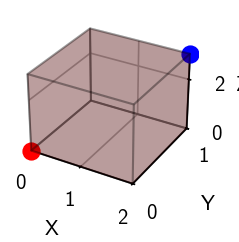

In [48]:
import itertools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import matplotlib as mpl

aggiemaroon = np.array([[80/255, 0, 0]])

# Corner points
p0 = (0, 0, 0)
p1 = (2, 1, 3)

# Generate all 8 vertices of the rectangular prism
xs = [p0[0], p1[0]]
ys = [p0[1], p1[1]]
zs = [p0[2], p1[2]]
verts = list(itertools.product(xs, ys, zs))

# Faces defined by vertex indices
faces = [
    [0, 1, 3, 2],  # z = p0.z
    [4, 5, 7, 6],  # z = p1.z
    [0, 1, 5, 4],  # y = p0.y
    [2, 3, 7, 6],  # y = p1.y
    [0, 2, 6, 4],  # x = p0.x
    [1, 3, 7, 5],  # x = p1.x
]

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 10, "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm", "mathtext.rm": "cm", "mathtext.sf": "cmss",
    "axes.unicode_minus": False,
})

fig = plt.figure(figsize=(2, 1.5), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

# Draw faces
poly3d = [[verts[i] for i in face] for face in faces]
ax.add_collection3d(Poly3DCollection(poly3d, alpha=0.2, facecolor=aggiemaroon, edgecolor="k"))

# Highlight the two marked points
ax.scatter(*p0, color="red", s=60, label="(0,0,0)")
ax.scatter(*p1, color="blue", s=60, label="(2,1,3)")

ax.set_yticks([0,1])

# Set bounds and labels
ax.set_xlim(min(xs), max(xs))
ax.set_ylim(min(ys), max(ys))
ax.set_zlim(min(zs), max(zs))
ax.set_xlabel("X",labelpad=0)
ax.set_ylabel("Y",labelpad=0)
ax.set_zlabel("Z",labelpad=-5)
ax.tick_params(axis="x", pad=0)
ax.tick_params(axis="y", pad=0)
ax.tick_params(axis="z", pad=1)  # z oft

fig.savefig("Figures/3d_box.png", dpi=500, bbox_inches="tight", pad_inches=0.15)
fig.savefig("Figures/3d_box_transparent.png", dpi=500, transparent=True, bbox_inches="tight", pad_inches=0.15)

## 6 - EI vs 1/Epsilon_X

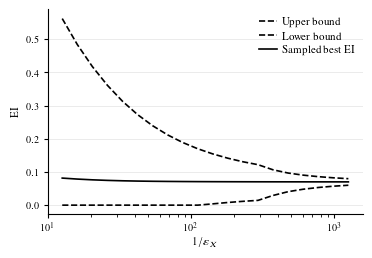

Selected box center: [0.51666667 0.18333333]
Intra-box samples per epsilon: 64
Saved figure to /Users/juanesfco/tamubo/development/figures/ei_bounds_vs_inv_epsilon_x.pdf


In [6]:
import math
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

NOTEBOOK_NAME = "exactBO_presentation.ipynb"
candidate_dirs = [Path.cwd(), Path.cwd() / "development"]
notebook_dir = next(
    (path for path in candidate_dirs if (path / NOTEBOOK_NAME).exists()),
    Path.cwd(),
)
repo_root = notebook_dir.parent if notebook_dir.name == "development" else notebook_dir
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from tamubo.acquisition_functions import expected_improvement
from tamubo.exactbo.bounds import ei_bounds, mu_bounds, rbf_k_bounds, sigma_bounds

mpl.rcParams.update(
    {
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage[helvratio=.91]{newtxtext}\usepackage{newtxmath}",
        "font.family": "serif",
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 8,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "lines.markersize": 4.0,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

FIGURE_WIDTH_PT = 257.28102
INCHES_PER_PT = 1.0 / 72.27
figure_width = FIGURE_WIDTH_PT * INCHES_PER_PT
figure_height = 0.68 * figure_width
output_dir = notebook_dir / "figures"
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "ei_bounds_vs_inv_epsilon_x.pdf"

def centered_latin_hypercube_unit(n_points: int, dim: int) -> np.ndarray:
    centers = (np.arange(n_points, dtype=np.float64) + 0.5) / float(n_points)
    perm_ids = np.arange(n_points, dtype=np.int64)
    lhs = np.empty((n_points, dim), dtype=np.float64)
    for j in range(dim):
        step = 2 * j + 1
        while math.gcd(step, n_points) != 1:
            step += 2
        lhs[:, j] = centers[(perm_ids * step + j) % n_points]
    return lhs

def sampled_box_best_ei(
    boxes_L: np.ndarray,
    boxes_U: np.ndarray,
    *,
    predict_with_std,
    sigma_n_2: float,
    y_min_scaled: float,
    lhs_unit_design: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    n_boxes, d = boxes_L.shape
    best_points = np.empty((n_boxes, d), dtype=np.float64)
    best_ei = np.empty((n_boxes,), dtype=np.float64)
    for box_index in range(n_boxes):
        box_width = boxes_U[box_index] - boxes_L[box_index]
        sampled_points = boxes_L[box_index] + lhs_unit_design * box_width
        mu, sigma = predict_with_std(sampled_points)
        sigma_lat = np.sqrt(np.clip(sigma**2 - sigma_n_2, 1e-12, None))
        ei = expected_improvement(mu, sigma_lat, y_min_scaled, backend="numpy")
        best_idx = int(np.argmax(ei))
        best_points[box_index] = sampled_points[best_idx]
        best_ei[box_index] = float(ei[best_idx])
    return best_points, best_ei

def objective(X: np.ndarray) -> np.ndarray:
    X = np.atleast_2d(np.asarray(X, dtype=np.float64))
    x1 = X[:, 0]
    x2 = X[:, 1]
    return (
        np.sin(2.0 * np.pi * (1.2 * x1 + 0.15)) * np.cos(2.0 * np.pi * (0.7 * x2 - 0.1))
        + 0.25 * (x1 - 0.72) ** 2
        + 0.15 * (x2 - 0.35) ** 2
    )

d = 2
X_train = centered_latin_hypercube_unit(12, d)
y_train = objective(X_train)

kernel = (
    ConstantKernel(1.0, (1e-2, 1e3))
    * RBF(length_scale=np.full(d, 0.2), length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-10, 1e-1))
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,
    normalize_y=True,
    n_restarts_optimizer=4,
    random_state=0,
)
gp.fit(X_train, y_train)

gp_kernel_params = gp.kernel_.get_params()
sigma_f_2 = float(gp_kernel_params["k1__k1__constant_value"])
sigma_n_2 = float(gp_kernel_params["k2__noise_level"])
length_scale = np.asarray(gp_kernel_params["k1__k2__length_scale"], dtype=np.float64)
alpha = np.asarray(gp.alpha_, dtype=np.float64).reshape(-1)
L = np.asarray(gp.L_, dtype=np.float64)
y_train_std = float(np.asarray(gp._y_train_std, dtype=np.float64).ravel()[0])
y_train_mean = float(np.asarray(gp._y_train_mean, dtype=np.float64).ravel()[0])
y_min_scaled = float(np.min(gp.y_train_))
N = X_train.shape[0]

def predict_with_std(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mu, sigma = gp.predict(np.asarray(points, dtype=np.float64), return_std=True)
    mu = (mu - y_train_mean) / y_train_std
    sigma = sigma / y_train_std
    return mu, sigma

# Choose a center in a high-EI region with enough room for nested boxes.
grid_1d = np.linspace(0.0, 1.0, 121)
grid = np.stack(np.meshgrid(grid_1d, grid_1d), axis=-1).reshape(-1, d)
mu_grid, sigma_grid = predict_with_std(grid)
sigma_grid_lat = np.sqrt(np.clip(sigma_grid**2 - sigma_n_2, 1e-12, None))
ei_grid = expected_improvement(mu_grid, sigma_grid_lat, y_min_scaled, backend="numpy")
margin = np.min(np.column_stack([grid, 1.0 - grid]), axis=1)
eligible = np.where(margin >= 0.18)[0]
center = grid[eligible[np.argmax(ei_grid[eligible])]] if eligible.size else grid[np.argmax(ei_grid)]

epsilons = np.geomspace(0.08, 0.0008, 20)
lhs_unit_design = centered_latin_hypercube_unit(64, d)

lower_bounds = []
upper_bounds = []
sampled_best = []

for epsilon in epsilons:
    half_width = 0.5 * epsilon * np.ones(d)
    box_L = center - half_width
    box_U = center + half_width

    K_lo = np.empty((1, N), dtype=np.float64)
    K_hi = np.empty((1, N), dtype=np.float64)
    for i in range(N):
        K_lo[:, i], K_hi[:, i] = rbf_k_bounds(
            box_L[None, :],
            box_U[None, :],
            X_train[i],
            1,
            d,
            sigma_f_2,
            length_scale,
            backend="numpy",
            validation=True,
        )

    mu_lo, mu_hi = mu_bounds(
        alpha,
        K_lo,
        K_hi,
        1,
        N,
        y_train_mean=y_train_mean,
        y_train_std=y_train_std,
        scaled_output=True,
        backend="numpy",
        validation=True,
    )
    sig_lo, sig_hi = sigma_bounds(
        K_lo,
        K_hi,
        L,
        1,
        N,
        sigma_f_2,
        y_train_std=y_train_std,
        scaled_output=True,
        backend="numpy",
        validation=True,
    )
    ei_lo, ei_hi = ei_bounds(
        mu_lo,
        mu_hi,
        sig_lo,
        sig_hi,
        1,
        y_min_scaled,
        backend="numpy",
        validation=True,
    )
    _, sampled_ei = sampled_box_best_ei(
        box_L[None, :],
        box_U[None, :],
        predict_with_std=predict_with_std,
        sigma_n_2=sigma_n_2,
        y_min_scaled=y_min_scaled,
        lhs_unit_design=lhs_unit_design,
    )

    lower_bounds.append(float(ei_lo[0]) * y_train_std)
    upper_bounds.append(float(ei_hi[0]) * y_train_std)
    sampled_best.append(float(sampled_ei[0]) * y_train_std)

inverse_eps = 1.0 / epsilons

fig, ax = plt.subplots(figsize=(figure_width, figure_height))
ax.plot(
    inverse_eps,
    upper_bounds,
    color="black",
    linestyle="--",
    label="Upper bound",
)
ax.plot(
    inverse_eps,
    lower_bounds,
    color="black",
    linestyle="--",
    label="Lower bound",
)
ax.plot(
    inverse_eps,
    sampled_best,
    color="black",
    linestyle="-",
    label="Sampled best EI",
)
ax.set_xscale("log")
ax.set_xlabel(r"$1 / \varepsilon_X$")
ax.set_ylabel("EI")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="0.88", linewidth=0.45)
ax.set_axisbelow(True)
ax.legend(
    frameon=False,
    loc="best",
    handlelength=1.6,
    handletextpad=0.5,
    borderpad=0.2,
    labelspacing=0.35,
)
fig.tight_layout(pad=0.15)
fig.savefig(output_path, bbox_inches="tight", pad_inches=0.02)
plt.show()
print(f"Selected box center: {center}")
print(f"Intra-box samples per epsilon: {lhs_unit_design.shape[0]}")
print(f"Saved figure to {output_path}")


## 7 - Time Comlexity

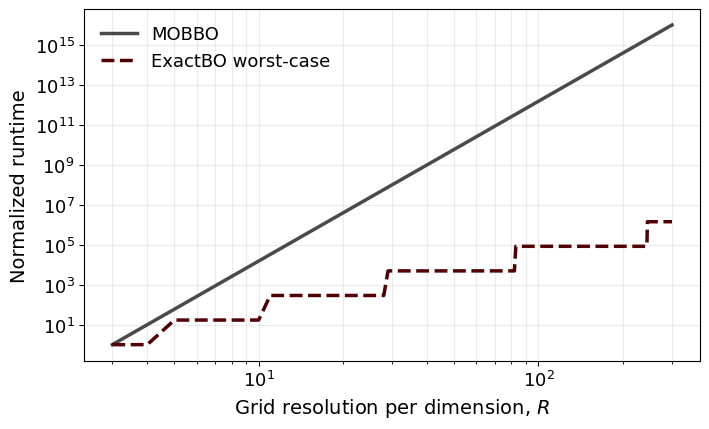

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
d = 8
R = np.arange(3, 301)
fontsize = 14

# Colors
maroon = "#500000"
dark_gray = "#4a4a4a"

# Runtime models
mobbo = R.astype(float) ** d
p = np.ceil(np.log(R - 1) / np.log(3))
exact_stair = (2 * d + 1) ** p
exact_asymp = (R - 1).astype(float) ** (np.log(2 * d + 1) / np.log(3))

# Normalize for shape comparison
mobbo_norm = mobbo / mobbo[0]
exact_stair_norm = exact_stair / exact_stair[0]
exact_asymp_norm = exact_asymp / exact_asymp[0]

# Slide-friendly figure size
fig, ax = plt.subplots(figsize=(7.2, 4.4))

ax.loglog(R, mobbo_norm, color=dark_gray, linewidth=2.5, label=r"MOBBO")
ax.loglog(R, exact_stair_norm, "--", color=maroon, linewidth=2.5, label=r"ExactBO worst-case")

ax.set_xlabel(r"Grid resolution per dimension, $R$", fontsize=fontsize)
ax.set_ylabel("Normalized runtime", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-1)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=fontsize-1, frameon=False)

plt.tight_layout()

fig.savefig("figures/exactbo_vs_mobbo_d8_transparent.png", dpi=400, transparent=True, bbox_inches="tight")
plt.show()

# 8 - Motivation

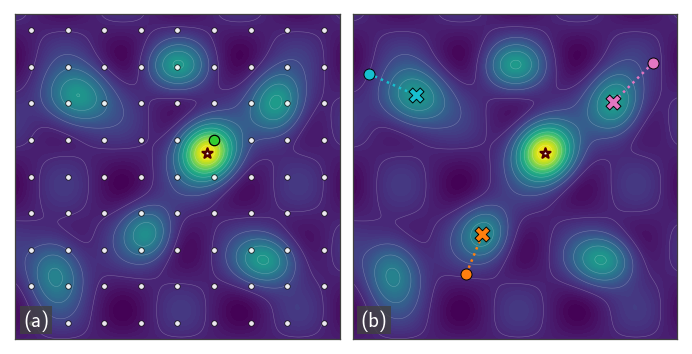

In [11]:
# Matplotlib figure for Motivation (1x2), CM Sans, 10pt, 4.5x3.5 in
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# --- typography & style ---
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Set global hatch linewidth
plt.rcParams['hatch.linewidth'] = 0.5

# LaTeX rendering optional (turn on if your env supports it)
# mpl.rcParams.update({
#     "text.usetex": True,
#     "text.latex.preamble": r"\usepackage{sfmath}\renewcommand{\familydefault}{\sfdefault}"
# })

aggiemaroon = np.array([[80/255, 0, 0]])

# --- multimodal acquisition function ---
# The narrow peak is the unique global maximum; the broader peaks and
# sinusoidal background create many attractive local maxima.
peaks = [
    (-2.25, -1.75, 0.72, 0.35, 0.44),
    (-1.85,  1.45, 0.88, 0.43, 0.38),
    (-0.55, -1.05, 0.74, 0.33, 0.35),
    ( 0.55,  0.45, 1.75, 0.37, 0.37),  # narrow global peak
    ( 1.65, -1.55, 0.84, 0.40, 0.32),
    ( 1.85,  1.35, 0.92, 0.35, 0.40),
    ( 0.00,  2.05, 0.72, 0.38, 0.30),
]

def acquisition(x, y):
    z = 0.16 * (np.cos(2.9*x - 0.2) * np.cos(2.7*y + 0.4) + 1.0)
    for cx, cy, amplitude, sx, sy in peaks:
        z += amplitude * np.exp(-0.5 * (((x-cx)/sx)**2 + ((y-cy)/sy)**2))
    return z

def acquisition_gradient(x, y):
    gx = -0.16 * 2.9 * np.sin(2.9*x - 0.2) * np.cos(2.7*y + 0.4)
    gy = -0.16 * 2.7 * np.cos(2.9*x - 0.2) * np.sin(2.7*y + 0.4)
    for cx, cy, amplitude, sx, sy in peaks:
        bump = amplitude * np.exp(-0.5 * (((x-cx)/sx)**2 + ((y-cy)/sy)**2))
        gx -= bump * (x-cx) / sx**2
        gy -= bump * (y-cy) / sy**2
    return np.array([gx, gy])

def gradient_ascent(start, step_size=0.025, n_steps=500):
    point = np.asarray(start, dtype=float)
    for _ in range(n_steps):
        point = np.clip(point + step_size * acquisition_gradient(*point), -2.95, 2.95)
    return point

# Evaluate the landscape once; both panels use the same Z, norm, and cmap.
axis = np.linspace(-3.0, 3.0, 601)
X, Y = np.meshgrid(axis, axis)
Z = acquisition(X, Y)
global_index = np.unravel_index(np.argmax(Z), Z.shape)
global_max = np.array([X[global_index], Y[global_index]])
norm = mpl.colors.Normalize(vmin=Z.min(), vmax=Z.max())

fig, axs = plt.subplots(1, 2, figsize=(4.5, 2.4), constrained_layout=True)

for ax in axs:
    ax.contourf(X, Y, Z, levels=80, cmap="viridis", norm=norm)
    ax.contour(X, Y, Z, levels=10, colors="white", linewidths=0.25, alpha=0.28)
    ax.scatter(*global_max, marker="*", s=25, facecolor="white",
               edgecolor=aggiemaroon[0], linewidth=1.1, zorder=7)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("0.25")

# Left: a finite grid selects its best sampled point, but the narrow global
# peak lies between grid points and is therefore missed.
grid_axis = np.linspace(-2.7, 2.7, 9)
GX, GY = np.meshgrid(grid_axis, grid_axis)
grid_values = acquisition(GX, GY)
grid_best_index = np.unravel_index(np.argmax(grid_values), grid_values.shape)
grid_best = np.array([GX[grid_best_index], GY[grid_best_index]])

axs[0].scatter(GX, GY, s=7, facecolor="white", edgecolor="black",
               linewidth=0.35, alpha=0.9, zorder=4)
axs[0].scatter(*grid_best, s=25, color="limegreen", edgecolor="black",
               linewidth=0.6, zorder=6)
#axs[0].set_title("Finite grid search", pad=4)

# Right: gradient ascent from three initializations converges to three
# different local maxima. Each dotted segment pairs a start (dot) with its
# converged endpoint (cross).
starts = np.array([[-2.70, 1.90], [-0.90, -1.80], [2.55, 2.10]])
ends = np.array([gradient_ascent(start) for start in starts])
pair_colors = ["tab:cyan", "tab:orange", "tab:pink"]

for start, end, color in zip(starts, ends, pair_colors):
    axs[1].plot([start[0], end[0]], [start[1], end[1]], linestyle=":",
                color=color, linewidth=1.2, zorder=4)
    axs[1].scatter(*start, s=28, marker="o", color=color, edgecolor="black",
                   linewidth=0.45, zorder=5)
    axs[1].scatter(*end, s=52, marker="X", color=color, edgecolor="black",
                   linewidth=0.45, zorder=6)

# Guard the intended visual story against accidental parameter changes.
assert np.linalg.norm(grid_best - global_max) > 0
assert np.all(np.linalg.norm(ends - global_max, axis=1) > 0)

for ax, panel_label in zip(axs, ("(a)", "(b)")):
    ax.text(0.025, 0.025, panel_label, transform=ax.transAxes, fontsize=10,
            color="white", ha="left", va="bottom", zorder=10,
            bbox=dict(facecolor="0.25", edgecolor="none", alpha=0.80, pad=1.5))

#axs[1].set_title("Gradient-based search", pad=4)
fig.savefig("figures/motivation_optimization_failures_transparent.png",
            dpi=400, transparent=True)
#, bbox_inches="tight"
plt.show()

# 9 - What is BO?

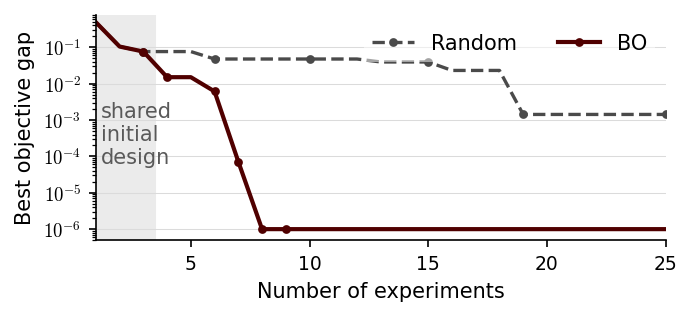

Saved figure to /Users/juanesfco/tamubo/development/figures/bo_vs_random_convergence.pdf

% Preamble requirements:
% \usepackage{tikz}
% \usetikzlibrary{arrows.meta,positioning}
% \definecolor{aggiemaroon}{RGB}{80,0,0}

\begin{frame}{What is Bayesian optimization?}
  \centering
  \small
  Use a probabilistic model to choose the next expensive experiment.
  \medskip

  \begin{columns}[c,onlytextwidth]
    \begin{column}{0.54\textwidth}
      \centering
      \begin{tikzpicture}[
        node distance=4mm and 4mm,
        stage/.style={
          draw=aggiemaroon, fill=aggiemaroon!7, rounded corners=1.2pt,
          align=center, minimum width=1.45cm, minimum height=0.72cm,
          inner sep=2.5pt, font=\scriptsize
        },
        flow/.style={-{Stealth[length=2mm]}, draw=aggiemaroon, thick}
      ]
        \node[stage] (data) {Initial\\data};
        \node[stage, right=of data] (model) {Fit surrogate\\model};
        \node[stage, right=of model] (predict) {Predict mean \\& uncertai

In [23]:
# What is BO? Slide figure and ready-to-paste Beamer/TikZ content
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

# --- typography and style consistent with the other presentation figures ---
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "DejaVu Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.unicode_minus": False,
})

aggiemaroon = "#500000"
dark_gray = "#4a4a4a"

# Resolve the output directory whether the notebook is run from the repo
# root or from development/.
notebook_name = "exactBO_presentation.ipynb"
candidate_dirs = [Path.cwd(), Path.cwd() / "development"]
notebook_dir = next(
    (path for path in candidate_dirs if (path / notebook_name).exists()),
    Path.cwd(),
)
output_dir = notebook_dir / "figures"
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "bo_vs_random_convergence.pdf"

# A smooth one-dimensional minimization problem. Both methods receive the
# same three initial observations; only their subsequent choices differ.
def objective(x):
    x = np.asarray(x, dtype=float)
    return (x - 0.73)**2 + 0.018 * np.sin(14.0 * x)

n_experiments = 25
initial_x = np.array([0.05, 0.42, 0.95])
candidate_grid = np.linspace(0.0, 1.0, 2001)
candidate_y = objective(candidate_grid)
true_minimum = float(candidate_y.min())

# Random experimentation: sample uniformly without using prior results.
rng = np.random.default_rng(11)
random_x = np.concatenate([
    initial_x,
    rng.uniform(0.0, 1.0, n_experiments - initial_x.size),
])
random_y = objective(random_x)
random_best = np.minimum.accumulate(random_y)

# Bayesian optimization: fit a Gaussian-process surrogate, then minimize a
# lower-confidence-bound acquisition function after every observation.
bo_x = initial_x.copy()
bo_y = objective(bo_x)
kernel = (
    ConstantKernel(1.0, constant_value_bounds="fixed")
    * RBF(0.18, length_scale_bounds="fixed")
    + WhiteKernel(1e-6, noise_level_bounds="fixed")
)

while bo_x.size < n_experiments:
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-8,
        normalize_y=True,
        optimizer=None,
    )
    gp.fit(bo_x[:, None], bo_y)
    posterior_mean, posterior_std = gp.predict(
        candidate_grid[:, None], return_std=True
    )
    acquisition = posterior_mean - 1.8 * posterior_std
    already_sampled = np.min(
        np.abs(candidate_grid[:, None] - bo_x[None, :]), axis=1
    ) < 1e-8
    next_index = int(np.argmin(np.where(already_sampled, np.inf, acquisition)))
    next_x = candidate_grid[next_index]
    bo_x = np.append(bo_x, next_x)
    bo_y = np.append(bo_y, objective(next_x))

bo_best = np.minimum.accumulate(bo_y)
experiment_number = np.arange(1, n_experiments + 1)
plot_floor = 1e-6
random_regret = np.maximum(random_best - true_minimum, plot_floor)
bo_regret = np.maximum(bo_best - true_minimum, plot_floor)

fig, ax = plt.subplots(figsize=(4.5, 2), constrained_layout=True)
ax.axvspan(0.5, 3.5, color="0.92", zorder=0)
ax.semilogy(
    experiment_number, random_regret,
    color=dark_gray, linestyle="--", linewidth=1.6,
    marker="o", markersize=3.2, markevery=[2, 5, 9, 14, 18, 24],
    label="Random",
)
ax.semilogy(
    experiment_number, bo_regret,
    color=aggiemaroon, linewidth=2.0,
    marker="o", markersize=3.2, markevery=[2, 3, 5, 6, 7, 8],
    label="BO",
)
ax.text(1.2, 4e-4, "shared\ninitial\ndesign", ha="left", va="center",
        fontsize=10, color="0.35")
ax.set_xlim(1, n_experiments)
ax.set_ylim(5e-7, 0.8)
ax.set_yticks([1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6])
ax.set_yticklabels([r"$10^{-1}$", r"$10^{-2}$", r"$10^{-3}$",
                    r"$10^{-4}$", r"$10^{-5}$", r"$10^{-6}$"])
ax.set_xlabel("Number of experiments")
ax.set_ylabel("Best objective gap")
ax.grid(axis="y", color="0.86", linewidth=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    frameon=True, facecolor="white", edgecolor="none", framealpha=0.5,
    loc="upper right", handlelength=2.0, ncol=2, fontsize=10,
)
fig.savefig(output_path, transparent=True)
plt.show()

# Ready-to-paste slide content. Add the two TikZ packages/libraries to the
# presentation preamble if they are not already present.
slide_latex = r"""
% Preamble requirements:
% \usepackage{tikz}
% \usetikzlibrary{arrows.meta,positioning}
% \definecolor{aggiemaroon}{RGB}{80,0,0}

\begin{frame}{What is Bayesian optimization?}
  \centering
  \small
  Use a probabilistic model to choose the next expensive experiment.
  \medskip

  \begin{columns}[c,onlytextwidth]
    \begin{column}{0.54\textwidth}
      \centering
      \begin{tikzpicture}[
        node distance=4mm and 4mm,
        stage/.style={
          draw=aggiemaroon, fill=aggiemaroon!7, rounded corners=1.2pt,
          align=center, minimum width=1.45cm, minimum height=0.72cm,
          inner sep=2.5pt, font=\scriptsize
        },
        flow/.style={-{Stealth[length=2mm]}, draw=aggiemaroon, thick}
      ]
        \node[stage] (data) {Initial\\data};
        \node[stage, right=of data] (model) {Fit surrogate\\model};
        \node[stage, right=of model] (predict) {Predict mean \\& uncertainty};
        \node[stage, below=of predict] (acquisition) {Optimize\\acquisition};
        \node[stage, left=of acquisition] (suggest) {Suggest next\\candidate};
        \node[stage, left=of suggest] (evaluate) {Evaluate \\& append};

        \draw[flow] (data) -- (model);
        \draw[flow] (model) -- (predict);
        \draw[flow] (predict) -- (acquisition);
        \draw[flow] (acquisition) -- (suggest);
        \draw[flow] (suggest) -- (evaluate);
        \draw[flow] (evaluate.south) -- ++(0,-0.38) -| (model.south);
      \end{tikzpicture}

      \vspace{1mm}
      {\scriptsize Repeat the loop until the experimental budget is exhausted.}
    \end{column}

    \begin{column}{0.44\textwidth}
      \centering
      \includegraphics[width=\linewidth]{figures/bo_vs_random_convergence.pdf}
    \end{column}
  \end{columns}
\end{frame}
"""

print(f"Saved figure to {output_path}")
print(slide_latex)

# 10 - Barometric Plots

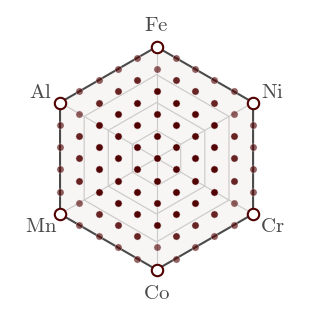

Saved 252-candidate grid to /Users/juanesfco/tamubo/development/figures/six_element_alloy_barycentric_grid.png


In [5]:
# Six-element barycentric alloy-design grid
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# --- typography and style consistent with the other presentation figures ---
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans",
        "DejaVu Sans", "cmss10", "cmss",
    ],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.unicode_minus": False,
})

aggiemaroon = "#500000"
dark_gray = "#4a4a4a"
light_gray = "#d2d2d2"

# Resolve the output directory whether the notebook is run from the repo
# root or from development/.
notebook_name = "exactBO_presentation.ipynb"
candidate_dirs = [Path.cwd(), Path.cwd() / "development"]
notebook_dir = next(
    (path for path in candidate_dirs if (path / notebook_name).exists()),
    Path.cwd(),
)
output_dir = notebook_dir / "figures"
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "six_element_alloy_barycentric_grid.png"

# Pure-element vertices of a regular hexagon. A composition c is projected
# to the weighted barycenter sum_i c_i v_i.
elements = np.array(["Fe", "Ni", "Cr", "Co", "Mn", "Al"])
angles = np.pi / 2 - np.arange(elements.size) * 2 * np.pi / elements.size
vertices = np.column_stack([np.cos(angles), np.sin(angles)])

# Simplex-lattice candidate grid: every component is a multiple of 20 at.%
# and all six fractions sum to one.
grid_denominator = 5

def integer_compositions(total, n_parts, prefix=()):
    if n_parts == 1:
        yield prefix + (total,)
        return
    for value in range(total + 1):
        yield from integer_compositions(
            total - value, n_parts - 1, prefix + (value,)
        )

candidate_counts = np.array(list(integer_compositions(
    grid_denominator, elements.size
)), dtype=float)
candidate_compositions = candidate_counts / grid_denominator
candidate_xy = candidate_compositions @ vertices

fig, ax = plt.subplots(figsize=(2, 2), constrained_layout=True)

# Reference frame: outer simplex projection, radial axes, and composition
# guide polygons.
for radius in (0.25, 0.50, 0.75):
    ax.add_patch(Polygon(
        radius * vertices, closed=True, facecolor="none",
        edgecolor=light_gray, linewidth=0.55, zorder=0,
    ))
for vertex in vertices:
    ax.plot([0, vertex[0]], [0, vertex[1]],
            color=light_gray, linewidth=0.55, zorder=0)
ax.add_patch(Polygon(
    vertices, closed=True, facecolor="#5000000a",
    edgecolor=dark_gray, linewidth=1.0, zorder=1,
))

# Candidate compositions. Overlapping projections naturally appear darker,
# indicating that a 2D view compresses the original five-dimensional simplex.
ax.scatter(
    candidate_xy[:, 0], candidate_xy[:, 1],
    s=12, facecolor=aggiemaroon, edgecolor="white", linewidth=0.25,
    alpha=0.62, zorder=3,
)

# Pure-element endmembers and labels.
ax.scatter(
    vertices[:, 0], vertices[:, 1], s=30, facecolor="white",
    edgecolor=aggiemaroon, linewidth=1.0, zorder=4,
)
for element, vertex in zip(elements, vertices):
    label_xy = 1.2 * vertex
    ax.text(
        label_xy[0], label_xy[1], rf"$\mathrm{{{element}}}$",
        ha="center", va="center", color=dark_gray, fontsize=10,
        fontweight="bold",
    )

ax.set_aspect("equal")
ax.set_xlim(-1.27, 1.27)
ax.set_ylim(-1.18, 1.23)
ax.axis("off")

fig.savefig(
    output_path, dpi=400, transparent=True
)
plt.show()
print(f"Saved {candidate_compositions.shape[0]}-candidate grid to {output_path}")